<a href="https://colab.research.google.com/github/jnrahul92/FastAI_Learn/blob/book/Fast_AI_C1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install fastai

In [ ]:
from fastai.vision.all import *

In [ ]:
path = untar_data(URLs.PETS)/'images'

In [ ]:
def is_cat(x): return x[0].isupper()

In [ ]:
dls = ImageDataLoaders.from_name_func(path, get_image_files(path),valid_pct=0.2, seed=42, label_func=is_cat, item_tfms=Resize(224))

In [ ]:
learn = cnn_learner(dls, resnet34, metrics=error_rate)
learn.fine_tune(1)

/usr/local/lib/python3.12/dist-packages/fastai/vision/learner.py:303: UserWarning: `cnn_learner` has been renamed to `vision_learner` -- please update your code
  warn("`cnn_learner` has been renamed to `vision_learner` -- please update your code")


Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 183MB/s]


epoch,train_loss,valid_loss,error_rate,time
0,0.157716,0.026246,0.006089,00:39


epoch,train_loss,valid_loss,error_rate,time
0,0.060628,0.013979,0.004060,00:45


In [ ]:
pip install ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 30.2 MB/s eta 0:00:00


In [ ]:
import ipywidgets as widgets

In [ ]:
uploader = widgets.FileUpload()

In [ ]:
uploader

FileUpload(value={}, description='Upload')

In [ ]:
img = PILImage.create(uploader.data[0])

In [ ]:
is_cat, _, probs = learn.predict(img)

In [ ]:
print(f"Is this a cat? : {is_cat}")
print(f"Probability it's a cat : {probs[1].item():.6f}")

Is this a cat? : True
Probability it's a cat : 1.000000


In [ ]:
path = untar_data(URLs.CAMVID_TINY)

In [ ]:
dls = SegmentationDataLoaders.from_label_func(path, bs=8, fnames=get_image_files(path/"images"),label_func=lambda o: path/'labels'/f'{o.stem}_P{o.suffix}',
                                              codes = np.loadtxt(path/'codes.txt',dtype=str))

In [ ]:
learn = unet_learner(dls, resnet34)

In [ ]:
learn.fine_tune(8)

epoch,train_loss,valid_loss,time
0,2.826765,2.426523,00:01


epoch,train_loss,valid_loss,time
0,1.840292,1.705095,00:01
1,1.606378,1.466382,00:01
2,1.431507,1.173689,00:01
3,1.275456,0.917176,00:01
4,1.127386,0.839688,00:01
5,1.009759,0.805083,00:01
6,0.917918,0.767600,00:01
7,0.845221,0.767892,00:01


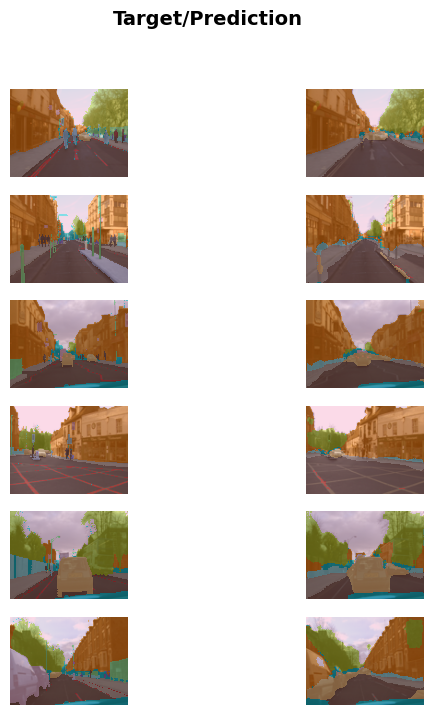

In [ ]:
learn.show_results(max_n=6, figsize=(7,8))

In [ ]:
from fastai.text.all import *

In [ ]:
dls = TextDataLoaders.from_folder(untar_data(URLs.IMDB), valid='test')

In [ ]:
learn = text_classifier_learner(dls, AWD_LSTM, drop_mult=0.5, metrics=accuracy)
learn.fine_tune(4, 1e-2)

epoch,train_loss,valid_loss,accuracy,time
0,0.473963,0.396838,0.824280,03:22


epoch,train_loss,valid_loss,accuracy,time
0,0.313160,0.320930,0.859800,07:04
1,0.244708,0.201685,0.921200,07:02
2,0.194082,0.192790,0.925720,07:02
3,0.162261,0.187026,0.931040,07:02


In [ ]:
learn.predict("I liked the first half of the movie very entertaining but as the story went on it became quite dull.")

('pos', tensor(1), tensor([0.2423, 0.7577]))

In [ ]:
learn.predict("Director should focus his energy on other business ventures.")

('neg', tensor(0), tensor([0.9403, 0.0597]))

In [ ]:
learn.predict("My God! What a snoozefest.")

('pos', tensor(1), tensor([0.3045, 0.6955]))

In [ ]:
from fastai.tabular.all import *

In [ ]:
path = untar_data(URLs.ADULT_SAMPLE)

In [ ]:
dls = TabularDataLoaders.from_csv(path/'adult.csv', path=path, y_names='salary',
                                  cat_names = ['workclass','education','marital-status','occupation',
                                               'relationship','race'],
                                  cont_names = ['age','fnlwgt','education-num'],
                                  procs = [Categorify, FillMissing, Normalize]
                                  )

/usr/local/lib/python3.12/dist-packages/fastai/tabular/core.py:314: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  to[n].fillna(self.na_dict[n], inplace=True)


In [ ]:
learn = tabular_learner(dls, metrics=accuracy)

In [ ]:
learn.fit_one_cycle(3)

epoch,train_loss,valid_loss,accuracy,time
0,0.378997,0.365582,0.833999,00:03
1,0.358958,0.356232,0.837684,00:03
2,0.349167,0.352001,0.839527,00:04


In [ ]:
from fastai.collab import *

In [ ]:
path = untar_data(URLs.ML_SAMPLE)

In [ ]:
dls = CollabDataLoaders.from_csv(path/'ratings.csv')
learn = collab_learner(dls, y_range=(0.5,5.5))

In [ ]:
learn.fine_tune(10)

epoch,train_loss,valid_loss,time
0,1.520125,1.430955,00:00


epoch,train_loss,valid_loss,time
0,1.344667,1.379273,00:00
1,1.278516,1.219617,00:00
2,1.067697,0.934330,00:00
3,0.814760,0.772872,00:00
4,0.691371,0.727185,00:00
5,0.632217,0.714535,00:00
6,0.608220,0.709966,00:00
7,0.603782,0.705694,00:00
8,0.581628,0.704501,00:00
9,0.585880,0.704350,00:00


In [ ]:
learn.show_results()

,userId,movieId,rating,rating_pred
0,85.0,70.0,5.0,4.147542
1,64.0,83.0,3.5,4.312088
2,11.0,31.0,4.5,3.666111
3,48.0,6.0,3.0,4.502983
4,49.0,15.0,4.0,4.360191
5,98.0,60.0,4.0,4.762629
6,94.0,62.0,4.5,4.034407
7,73.0,89.0,4.0,3.648809
8,88.0,77.0,3.5,4.032954
